# Movie Recommendation System
**Dataset:** The Movies Dataset — rounakbanik (Kaggle)
**By:** Subin Thapa

**Pipeline:** Data Load → Cleaning → EDA → Weighted Score → Feature Engineering → Train-Test Split → Baseline → Logistic Regression → Decision Tree → Naive Bayes → Model Comparison → Content-Based → SVD → Hybrid Recommender
### Can we predict whether a user will like a movie, and recommend movies they're likely to enjoy, using rating history and movie metadata?

---
## Step 1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error
)

print('All libraries imported!')
# Expected output: All libraries imported!

All libraries imported!


---
## Step 2  Load Data

In [2]:
movies   = pd.read_csv(r'E:\movie-recommendation-system\data\movies_metadata.csv', low_memory=False)
ratings  = pd.read_csv(r'E:\movie-recommendation-system\data\ratings.csv')
links    = pd.read_csv(r'E:\movie-recommendation-system\data\links.csv')
credits  = pd.read_csv(r'E:\movie-recommendation-system\data\credits.csv')
keywords = pd.read_csv(r'E:\movie-recommendation-system\data\keywords.csv')

print('movies_metadata :', movies.shape)
print('ratings_small   :', ratings.shape)
print('links_small     :', links.shape)
print('credits         :', credits.shape)
print('keywords        :', keywords.shape)

movies_metadata : (45466, 24)
ratings_small   : (26024289, 4)
links_small     : (45843, 3)
credits         : (45476, 3)
keywords        : (46419, 2)


---
## Step 3  Data Cleaning

In [4]:
# Remove corrupt rows with non-numeric id
movies = movies[pd.to_numeric(movies['id'], errors='coerce').notnull()].copy()
movies['id'] = movies['id'].astype(int)

# Keep only needed columns
movies = movies[[
    'id', 'title', 'genres', 'overview',
    'vote_average', 'vote_count', 'release_date',
    'runtime', 'original_language', 'popularity'
]].copy()

# Fix data types
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce').fillna(0)
movies['vote_count']   = pd.to_numeric(movies['vote_count'],   errors='coerce').fillna(0)
movies['popularity']   = pd.to_numeric(movies['popularity'],   errors='coerce').fillna(0)
movies['overview']     = movies['overview'].fillna('')
movies['year']         = pd.to_datetime(movies['release_date'], errors='coerce').dt.year

print('Movies cleaned shape:', movies.shape)
print('Null check:')
print(movies.isnull().sum())
# Expected output:
# Movies cleaned shape: (45463, 11)
# All nulls should be 0 except year and runtime

Movies cleaned shape: (45463, 11)
Null check:
id                     0
title                  3
genres                 0
overview               0
vote_average           0
vote_count             0
release_date          87
runtime              260
original_language     11
popularity             0
year                  87
dtype: int64


---
## Step 4 Parse Genres

In [ ]:
# genres column is stored as stringified JSON list
# Example: "[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}]"
def parse_genres(genre_str):
    try:
        return [g['name'] for g in ast.literal_eval(genre_str)]
    except:
        return []

movies['genre_list'] = movies['genres'].apply(parse_genres)
movies['genre_str']  = movies['genre_list'].apply(lambda x: ' '.join(x))

print('Genres parsed successfully!')
print(movies[['title', 'genre_list']].head(3).to_string())

Genres parsed successfully!
              title                    genre_list
0         Toy Story   [Animation, Comedy, Family]
1           Jumanji  [Adventure, Fantasy, Family]
2  Grumpier Old Men             [Romance, Comedy]


---
## Step 5  Parse Credits & Keywords

In [6]:
credits['id']  = credits['id'].astype(int)
keywords['id'] = keywords['id'].astype(int)

def get_director(crew_str):
    try:
        for person in ast.literal_eval(crew_str):
            if person['job'] == 'Director':
                return person['name']
    except:
        pass
    return ''

def get_top_cast(cast_str, n=3):
    try:
        return [c['name'] for c in ast.literal_eval(cast_str)[:n]]
    except:
        return []

def get_keywords(kw_str):
    try:
        return [k['name'] for k in ast.literal_eval(kw_str)]
    except:
        return []

credits['director']      = credits['crew'].apply(get_director)
credits['cast_list']     = credits['cast'].apply(get_top_cast)
keywords['keyword_list'] = keywords['keywords'].apply(get_keywords)

movies = movies.merge(credits[['id', 'director', 'cast_list']], on='id', how='left')
movies = movies.merge(keywords[['id', 'keyword_list']],         on='id', how='left')

movies['director']     = movies['director'].fillna('')
movies['cast_list']    = movies['cast_list'].apply(lambda x: x if isinstance(x, list) else [])
movies['keyword_list'] = movies['keyword_list'].apply(lambda x: x if isinstance(x, list) else [])

print('Credits & keywords merged!')
print('Movies shape now:', movies.shape)
print(movies[['title','director','cast_list']].head(2).to_string())


Credits & keywords merged!
Movies shape now: (46629, 16)
       title       director                                       cast_list
0  Toy Story  John Lasseter             [Tom Hanks, Tim Allen, Don Rickles]
1    Jumanji   Joe Johnston  [Robin Williams, Jonathan Hyde, Kirsten Dunst]


---
## Step 6  Merge Ratings + Links + Movies

In [7]:
links = links.dropna(subset=['tmdbId']).copy()
links['tmdbId'] = links['tmdbId'].astype(int)

df = ratings.merge(links[['movieId', 'tmdbId']], on='movieId', how='inner')
df = df.merge(
    movies[['id','title','genre_list','genre_str',
            'vote_average','vote_count','year','director','overview']],
    left_on='tmdbId', right_on='id', how='inner'
)
df = df.drop(columns=['id','timestamp'])

print('Merged df shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(3).to_string())

Merged df shape: (26068074, 12)
Columns: ['userId', 'movieId', 'rating', 'tmdbId', 'title', 'genre_list', 'genre_str', 'vote_average', 'vote_count', 'year', 'director', 'overview']
   userId  movieId  rating  tmdbId                   title                     genre_list                 genre_str  vote_average  vote_count    year              director                                                                                                                                                                                                                                                                                                             overview
0       1      110     1.0     197              Braveheart  [Action, Drama, History, War]  Action Drama History War           7.7      3404.0  1995.0            Mel Gibson                                                   Enraged at the slaughter of Murron, his new bride and childhood love, Scottish warrior William Wallace slays a plato

---
## Step 7 Basic EDA

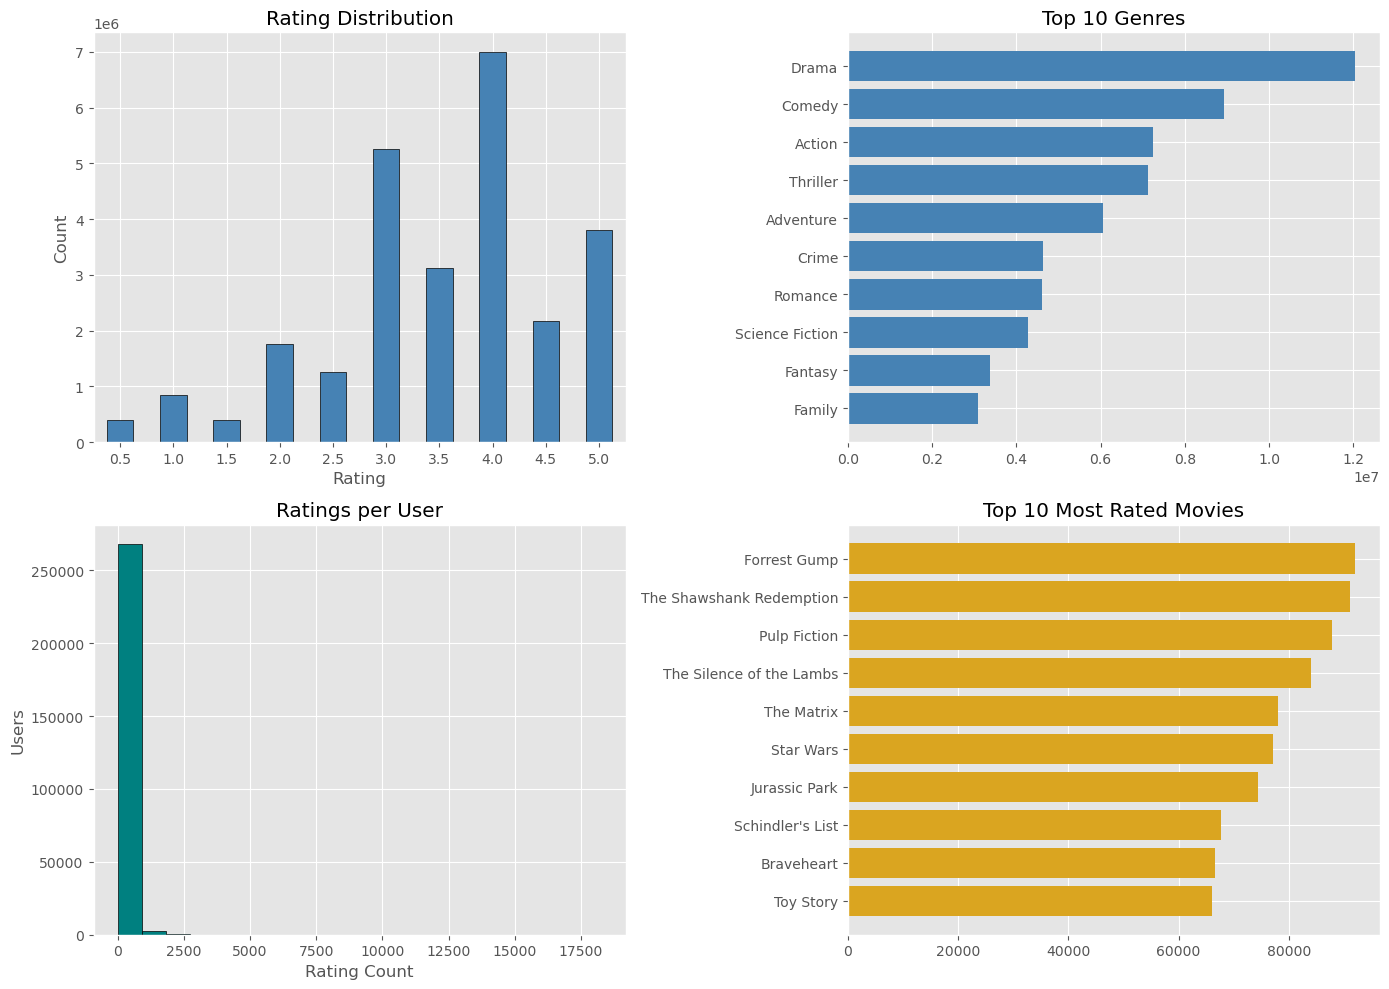

Average rating     : 3.53
Most common rating : 4.0
Avg ratings/user   : 96.1
Top genre          : Drama


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating Distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Top 10 Genre Frequency
all_genres   = df['genre_list'].explode().dropna()
genre_counts = Counter(all_genres)
genre_df     = pd.DataFrame(genre_counts.items(), columns=['genre','count']).sort_values('count', ascending=False).head(10)
axes[0,1].barh(genre_df['genre'], genre_df['count'], color='steelblue')
axes[0,1].set_title('Top 10 Genres')
axes[0,1].invert_yaxis()

# 3. Ratings per User
user_activity = ratings.groupby('userId')['rating'].count()
axes[1,0].hist(user_activity, bins=20, color='teal', edgecolor='black')
axes[1,0].set_title('Ratings per User')
axes[1,0].set_xlabel('Rating Count')
axes[1,0].set_ylabel('Users')

# 4. Top 10 Most Rated Movies
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
axes[1,1].barh(top_movies.index, top_movies.values, color='goldenrod')
axes[1,1].set_title('Top 10 Most Rated Movies')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()
plt.close()

print(f'Average rating     : {round(ratings["rating"].mean(), 2)}')
print(f'Most common rating : {ratings["rating"].mode()[0]}')
print(f'Avg ratings/user   : {round(user_activity.mean(), 1)}')
print(f'Top genre          : {genre_df.iloc[0]["genre"]}')

In [9]:
print(df.shape)

(26068074, 12)


---
## Step 7b  Average Rating per Genre

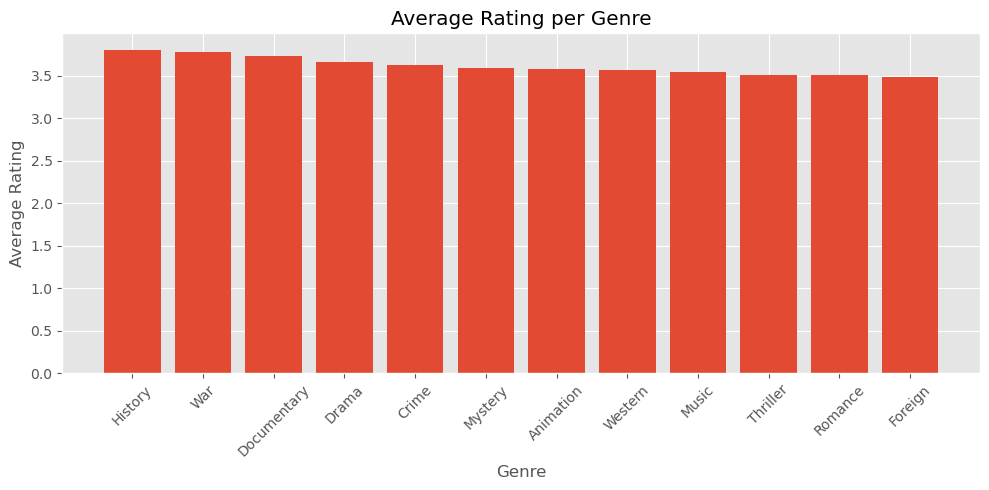

          Genre  Average Rating
14      History        3.808863
6           War        3.775034
16  Documentary        3.732965
5         Drama        3.660663
7         Crime        3.623769
13      Mystery        3.593835
11    Animation        3.574490
17      Western        3.563164
15        Music        3.539432
4      Thriller        3.511826
0       Romance        3.506713
19      Foreign        3.485083


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Take a sample to reduce memory usage
sample_df = df.sample(
    n=min(500000, len(df)),
    random_state=42
)

genre_sum = defaultdict(float)
genre_count = defaultdict(int)

for genres, rating in zip(
    sample_df['genre_list'],
    sample_df['rating']
):

    if not isinstance(genres, list):
        continue

    if pd.isna(rating):
        continue

    for genre in genres:
        genre_sum[genre] += rating
        genre_count[genre] += 1

avg_ratings = {
    genre: genre_sum[genre] / genre_count[genre]
    for genre in genre_sum
}

avg_genre_rating = pd.DataFrame(
    avg_ratings.items(),
    columns=['Genre', 'Average Rating']
)

avg_genre_rating = avg_genre_rating.sort_values(
    'Average Rating',
    ascending=False
).head(12)

plt.figure(figsize=(10, 5))
plt.bar(
    avg_genre_rating['Genre'],
    avg_genre_rating['Average Rating']
)
plt.title('Average Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(avg_genre_rating)

---
## Step 8  Weighted Rating Score (IMDB Formula)

Formula:
```
Weighted Score = (v / (v+m)) * R + (m / (v+m)) * C
v = vote count of movie
m = minimum votes required (70th percentile)
R = average rating of movie
C = mean rating across all movies
```

In [ ]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.70)

print(f'Mean rating across all movies (C) : {round(C, 2)}')
print(f'Minimum vote threshold (m)        : {round(m, 0)}')

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

qualified = movies[movies['vote_count'] >= m].copy()
qualified['weighted_score'] = qualified.apply(weighted_rating, axis=1)

top_weighted = qualified.sort_values('weighted_score', ascending=False)[
    ['title','vote_average','vote_count','weighted_score']
].head(10)

print(f'\nMovies with enough votes: {len(qualified)}')
print('\nTop 10 Movies by Weighted Score:')
print(top_weighted.to_string(index=False))


Mean rating across all movies (C) : 5.61
Minimum vote threshold (m)        : 25.0

Movies with enough votes: 14046

Top 10 Movies by Weighted Score:
                      title  vote_average  vote_count  weighted_score
Dilwale Dulhania Le Jayenge           9.1       661.0        8.972854
   The Shawshank Redemption           8.5      8358.0        8.491385
              The Godfather           8.5      6024.0        8.488061
                 Your Name.           8.5      1030.0        8.431543
               Planet Earth           8.8       176.0        8.403374
            The Dark Knight           8.3     12269.0        8.294532
                 Fight Club           8.3      9678.0        8.293072
               Pulp Fiction           8.3      8670.0        8.292269
           Schindler's List           8.3      4436.0        8.284931
                   Whiplash           8.3      4376.0        8.284726


---
## Step 9  Feature Engineering

In [ ]:
# Binary target: liked = 1 if rating >= 4.0
df['liked'] = (df['rating'] >= 4.0).astype(int)

print('Target (liked) distribution:')
print(df['liked'].value_counts())
print(f'Liked %: {round(df["liked"].mean()*100, 2)}%')


Target (liked) distribution:
liked
0    13075507
1    12992567
Name: count, dtype: int64
Liked %: 49.84%


In [13]:
# Genre one-hot encoding (memory-safe — avoids materializing huge intermediate arrays)
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list']).astype(np.int8)  # int8 keeps memory tiny
genre_dummies = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=df.index)
genre_columns = mlb.classes_.tolist()

df = pd.concat([df, genre_dummies], axis=1)

# User average rating — how generous is this user
user_avg  = df.groupby('userId')['rating'].mean().rename('user_avg_rating')
df        = df.join(user_avg, on='userId')

# Movie average rating — how good is this movie overall
movie_avg = df.groupby('movieId')['rating'].mean().rename('movie_avg_rating')
df        = df.join(movie_avg, on='movieId')

print('Genre columns created:', len(genre_columns))
print('New features: user_avg_rating, movie_avg_rating')
print('Final df shape:', df.shape)


Genre columns created: 20
New features: user_avg_rating, movie_avg_rating
Final df shape: (26068074, 35)


In [14]:
df['liked'] = (df['rating'] >= 4.0).astype(int)
print(df['liked'].value_counts())
print(f'Liked %: {round(df["liked"].mean()*100, 2)}%')                # should be True            # should be True

liked
0    13075507
1    12992567
Name: count, dtype: int64
Liked %: 49.84%


In [15]:
print(df['liked'].isna().sum())              # should be 0
print(df[genre_columns].isna().sum().sum())  # should be 0
print(df.index.is_unique) 

0
0
True


---
## Step 10  Train-Test Split

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_ml = df.sample(n=500000, random_state=42)

print("ML dataset shape:", df_ml.shape)
# 2. Select safe feature columns

feature_cols = [
    'user_avg_rating',
    'movie_avg_rating',
    'vote_average',
    'vote_count'
]

# add genre columns ONLY if they exist AND are not too many
if 'genre_columns' in globals():
    feature_cols += list(genre_columns)

# 3. Build dataset safely

model_df = df_ml[feature_cols + ['liked']].dropna()

X = model_df[feature_cols]
y = model_df['liked']

# 4. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Scale features (important for logistic regression)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Output Info
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Liked ratio (train):", y_train.mean())
print("Liked ratio (test) :", y_test.mean())

ML dataset shape: (500000, 35)
Train size: (400000, 24)
Test size : (100000, 24)
Liked ratio (train): 0.4971775
Liked ratio (test) : 0.49718


---
## Step 11  Baseline Model

In [ ]:
majority_class = int(y_train.mode()[0])
baseline_preds = [majority_class] * len(y_test)

print(f'Majority class    : {majority_class}')
print(f'Baseline Accuracy : {accuracy_score(y_test, baseline_preds):.2%}')
print(f'Baseline F1       : {f1_score(y_test, baseline_preds, zero_division=0):.4f}')
print('Any model must beat this!')

Majority class    : 0
Baseline Accuracy : 50.28%
Baseline F1       : 0.0000
Any model must beat this!


---
## Step 12  Logistic Regression

=== Logistic Regression ===
Train RMSE : 0.5362
Test RMSE  : 0.5356
Test MAE   : 0.2869
Accuracy   : 71.31%
F1 Score   : 0.7157

              precision    recall  f1-score   support

   Not Liked       0.72      0.70      0.71     50282
       Liked       0.71      0.73      0.72     49718

    accuracy                           0.71    100000
   macro avg       0.71      0.71      0.71    100000
weighted avg       0.71      0.71      0.71    100000



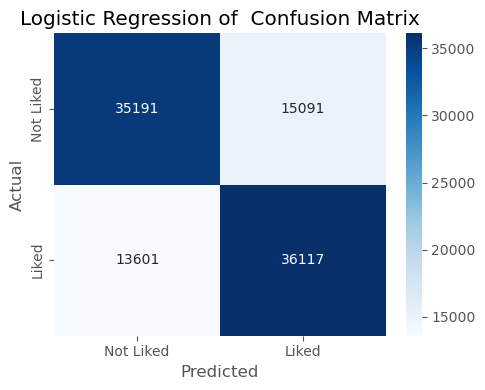

In [41]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds       = lr.predict(X_test_scaled)
lr_train_preds = lr.predict(X_train_scaled)

print('=== Logistic Regression ===')
print(f'Train RMSE : {mean_squared_error(y_train, lr_train_preds)**0.5:.4f}')
print(f'Test RMSE  : {mean_squared_error(y_test,  lr_preds)**0.5:.4f}')
print(f'Test MAE   : {mean_absolute_error(y_test,  lr_preds):.4f}')
print(f'Accuracy   : {accuracy_score(y_test, lr_preds):.2%}')
print(f'F1 Score   : {f1_score(y_test, lr_preds):.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['Not Liked','Liked']))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Liked','Liked'], yticklabels=['Not Liked','Liked'])
plt.title('Logistic Regression of  Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
plt.close()

---
## Step 13  Decision Tree

=== Decision Tree ===
Train RMSE : 0.5384
Test RMSE  : 0.5406
Test MAE   : 0.2922
Accuracy   : 70.78%
F1 Score   : 0.7085

              precision    recall  f1-score   support

   Not Liked       0.71      0.70      0.71     50282
       Liked       0.70      0.71      0.71     49718

    accuracy                           0.71    100000
   macro avg       0.71      0.71      0.71    100000
weighted avg       0.71      0.71      0.71    100000



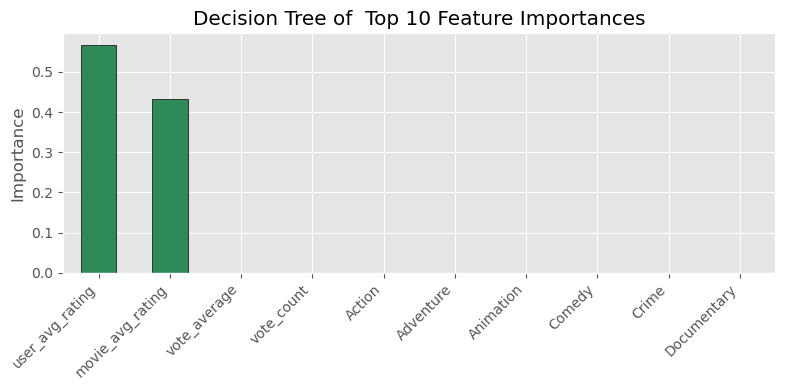

In [42]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds       = dt.predict(X_test)
dt_train_preds = dt.predict(X_train)

print('=== Decision Tree ===')
print(f'Train RMSE : {mean_squared_error(y_train, dt_train_preds)**0.5:.4f}')
print(f'Test RMSE  : {mean_squared_error(y_test,  dt_preds)**0.5:.4f}')
print(f'Test MAE   : {mean_absolute_error(y_test,  dt_preds):.4f}')
print(f'Accuracy   : {accuracy_score(y_test, dt_preds):.2%}')
print(f'F1 Score   : {f1_score(y_test, dt_preds):.4f}')
print()
print(classification_report(y_test, dt_preds, target_names=['Not Liked','Liked']))

# Feature importance
feat_imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
feat_imp.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Decision Tree of  Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

---
## Step 14  Naive Bayes

=== Naive Bayes ===
Train RMSE : 0.5740
Test RMSE  : 0.5728
Test MAE   : 0.3281
Accuracy   : 67.19%
F1 Score   : 0.6635

              precision    recall  f1-score   support

   Not Liked       0.67      0.69      0.68     50282
       Liked       0.68      0.65      0.66     49718

    accuracy                           0.67    100000
   macro avg       0.67      0.67      0.67    100000
weighted avg       0.67      0.67      0.67    100000



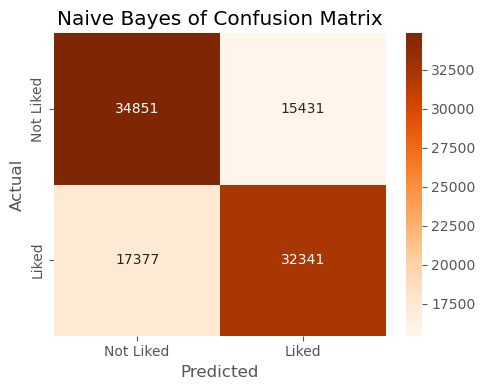

In [43]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_preds       = nb.predict(X_test)
nb_train_preds = nb.predict(X_train)

print('=== Naive Bayes ===')
print(f'Train RMSE : {mean_squared_error(y_train, nb_train_preds)**0.5:.4f}')
print(f'Test RMSE  : {mean_squared_error(y_test,  nb_preds)**0.5:.4f}')
print(f'Test MAE   : {mean_absolute_error(y_test,  nb_preds):.4f}')
print(f'Accuracy   : {accuracy_score(y_test, nb_preds):.2%}')
print(f'F1 Score   : {f1_score(y_test, nb_preds):.4f}')
print()
print(classification_report(y_test, nb_preds, target_names=['Not Liked','Liked']))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Liked','Liked'], yticklabels=['Not Liked','Liked'])
plt.title('Naive Bayes of Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
plt.close()

---
## Step 15  Model Comparison

=== Final Model Comparison ===
              Model Train RMSE Test RMSE Test MAE Accuracy F1 Score
           Baseline          -    0.7051   0.4972   50.28%   0.0000
Logistic Regression     0.5362    0.5356   0.2869   71.31%   0.7157
      Decision Tree     0.5384    0.5406   0.2922   70.78%   0.7085
        Naive Bayes     0.5740    0.5728   0.3281   67.19%   0.6635


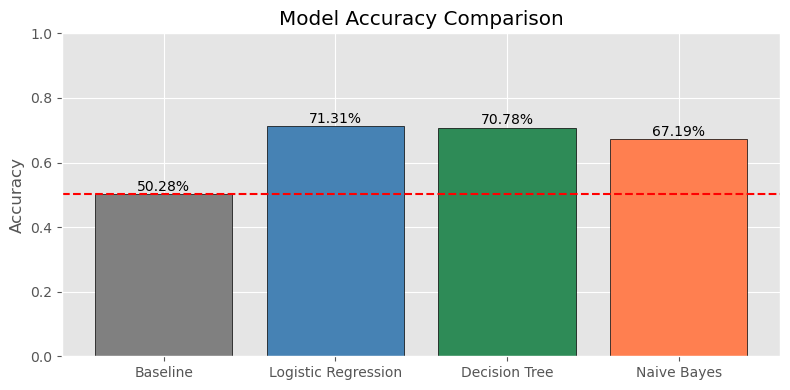

In [24]:
results = pd.DataFrame({
    'Model'      : ['Baseline','Logistic Regression','Decision Tree','Naive Bayes'],
    'Train RMSE' : ['-',
        f'{mean_squared_error(y_train, lr_train_preds)**0.5:.4f}',
        f'{mean_squared_error(y_train, dt_train_preds)**0.5:.4f}',
        f'{mean_squared_error(y_train, nb_train_preds)**0.5:.4f}'],
    'Test RMSE'  : [
        f'{mean_squared_error(y_test, baseline_preds)**0.5:.4f}',
        f'{mean_squared_error(y_test, lr_preds)**0.5:.4f}',
        f'{mean_squared_error(y_test, dt_preds)**0.5:.4f}',
        f'{mean_squared_error(y_test, nb_preds)**0.5:.4f}'],
    'Test MAE'   : [
        f'{mean_absolute_error(y_test, baseline_preds):.4f}',
        f'{mean_absolute_error(y_test, lr_preds):.4f}',
        f'{mean_absolute_error(y_test, dt_preds):.4f}',
        f'{mean_absolute_error(y_test, nb_preds):.4f}'],
    'Accuracy'   : [
        f'{accuracy_score(y_test, baseline_preds):.2%}',
        f'{accuracy_score(y_test, lr_preds):.2%}',
        f'{accuracy_score(y_test, dt_preds):.2%}',
        f'{accuracy_score(y_test, nb_preds):.2%}'],
    'F1 Score'   : [
        f'{f1_score(y_test, baseline_preds, zero_division=0):.4f}',
        f'{f1_score(y_test, lr_preds):.4f}',
        f'{f1_score(y_test, dt_preds):.4f}',
        f'{f1_score(y_test, nb_preds):.4f}']
})

print('=== Final Model Comparison ===')
print(results.to_string(index=False))

# Bar chart
accs = [accuracy_score(y_test, p) for p in [baseline_preds, lr_preds, dt_preds, nb_preds]]
plt.figure(figsize=(8,4))
bars = plt.bar(results['Model'], accs, color=['gray','steelblue','seagreen','coral'], edgecolor='black')
plt.axhline(y=accs[0], color='red', linestyle='--', label='Baseline')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
for bar, val in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.2%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

---
## Step 16 Content-Based Filtering

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Rebuild content from scratch, fully fresh
content = movies[['id','title','genre_str','overview','director','cast_list','keyword_list']].copy()
content = content.dropna(subset=['title']).reset_index(drop=True)

content['cast_str']    = content['cast_list'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
content['keyword_str'] = content['keyword_list'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
content['soup']        = (content['genre_str']   + ' ' +
                          content['overview']    + ' ' +
                          content['director']    + ' ' +
                          content['cast_str']    + ' ' +
                          content['keyword_str'])

tfidf        = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf.fit_transform(content['soup'])
indices      = pd.Series(content.index, index=content['title']).drop_duplicates()

print('content rows       :', len(content))
print('tfidf_matrix shape  :', tfidf_matrix.shape)
print('Shapes match        :', len(content) == tfidf_matrix.shape[0])

content rows       : 46625
tfidf_matrix shape  : (46625, 10000)
Shapes match        : True


In [26]:
print('tfidf_matrix' in globals())
print('content' in globals())
print('indices' in globals())
print('movies' in globals())

True
True
True
True


In [27]:
def content_recommend(title, n=10):
    if title not in indices:
        print(f"'{title}' not found.")
        return
    idx        = indices[title]
    sim_row    = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores = sorted(list(enumerate(sim_row)), key=lambda x: x[1], reverse=True)[1:n+1]
    result     = content[['title','genre_str']].iloc[[i[0] for i in sim_scores]].copy()
    result['similarity_score'] = [round(s[1], 4) for s in sim_scores]
    return result.reset_index(drop=True)

print('Content-Based Recommendations for The Dark Knight:')
print(content_recommend('The Dark Knight').to_string())
print()
print('Content-Based Recommendations for Toy Story:')
print(content_recommend('Toy Story').to_string())

Content-Based Recommendations for The Dark Knight:
                                                                title                               genre_str  similarity_score
0                                                     The Dark Knight             Drama Action Crime Thriller            1.0000
1                                               The Dark Knight Rises             Action Crime Drama Thriller            0.5054
2                                                       Batman Begins                      Action Crime Drama            0.4485
3                                          Batman: Under the Red Hood                        Action Animation            0.4182
4                                                      Batman Returns                          Action Fantasy            0.4007
5                                                      Batman Forever                    Action Crime Fantasy            0.3549
6                                                    

---
## Step 17 User-Item Matrix (SVD Collaborative Filtering)

**How it works:**
1. Build matrix: rows = users, columns = movies, values = ratings
2. SVD decomposes it into latent factors (hidden patterns)
3. Reconstruct to get predicted ratings for all user-movie pairs
4. Metric: RMSE and MAE only (regression, not classification)

In [28]:
import psutil
mem = psutil.virtual_memory()
print(f'Total RAM : {mem.total / 1e9:.1f} GB')
print(f'Available : {mem.available / 1e9:.1f} GB')
print(f'Used      : {mem.percent}%')

Total RAM : 17.1 GB
Available : 4.5 GB
Used      : 73.9%


In [29]:
from scipy.sparse import csr_matrix

global_mean = ratings['rating'].mean()  # used to center the matrix and un-center predictions later

user_idx, user_ids_lookup   = pd.factorize(ratings['userId'].values, sort=True)
movie_idx, movie_ids_lookup = pd.factorize(ratings['movieId'].values, sort=True)

n_users  = len(user_ids_lookup)
n_movies = len(movie_ids_lookup)

# Mean-center ratings BEFORE building the sparse matrix.
# Without this, "no rating" (0 after fillna) gets treated as "rated 0/hated it",
# which badly distorts SVD on very sparse data. Centering makes 0 mean "average".
centered_values = ratings['rating'].values - global_mean

user_item_sparse = csr_matrix(
    (centered_values, (user_idx, movie_idx)),
    shape=(n_users, n_movies)
)

user_pos  = {uid: i for i, uid in enumerate(user_ids_lookup)}
movie_pos = {mid: i for i, mid in enumerate(movie_ids_lookup)}

sparsity = 1 - (ratings.shape[0] / (n_users * n_movies))
print(f'User-Item matrix shape : {user_item_sparse.shape}')
print(f'Sparsity               : {sparsity:.2%}')

svd          = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(user_item_sparse)
item_factors = svd.components_

print(f'User factors shape     : {user_factors.shape}')
print(f'Item factors shape     : {item_factors.shape}')
print(f'Variance explained     : {svd.explained_variance_ratio_.sum():.2%}')

User-Item matrix shape : (270896, 45115)
Sparsity               : 99.79%
User factors shape     : (270896, 50)
Item factors shape     : (50, 45115)
Variance explained     : 20.59%


In [30]:
# RMSE and MAE for SVD — regression metrics only, no accuracy
valid_mask    = ratings['userId'].isin(user_pos) & ratings['movieId'].isin(movie_pos)
valid_ratings = ratings[valid_mask]

u_positions = valid_ratings['userId'].map(user_pos).values
m_positions = valid_ratings['movieId'].map(movie_pos).values
actual      = valid_ratings['rating'].values

n = len(actual)
chunk_size = 500_000
predicted_centered = np.empty(n, dtype=np.float64)

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)
    u_chunk = u_positions[start:end]
    m_chunk = m_positions[start:end]
    predicted_centered[start:end] = np.einsum(
        'ij,ij->i',
        user_factors[u_chunk],
        item_factors[:, m_chunk].T
    )

predicted_arr = predicted_centered + global_mean   # un-center: add the global mean back

print('Sanity check — predicted_arr mean (should be close to actual mean):')
print('  predicted_arr mean:', predicted_arr.mean())
print('  actual mean       :', actual.mean())
print()

base_preds_svd = np.full(len(actual), global_mean)

base_rmse = mean_squared_error(actual, base_preds_svd) ** 0.5
base_mae  = mean_absolute_error(actual, base_preds_svd)
svd_rmse  = mean_squared_error(actual, predicted_arr)  ** 0.5
svd_mae   = mean_absolute_error(actual, predicted_arr)

print('=== SVD Collaborative Filtering ===')
print()
print(' Base Model (Mean Predictor)')
print(f' RMSE = {round(base_rmse, 4)}')
print(f' MAE  = {round(base_mae,  4)}')
print()
print(' SVD Model')
print(f' RMSE = {round(svd_rmse, 4)}')
print(f' MAE  = {round(svd_mae,  4)}')
print()
print(f' RMSE improved by {round(base_rmse-svd_rmse,4)} ({round((base_rmse-svd_rmse)/base_rmse*100,1)}%)')
print(f' MAE  improved by {round(base_mae-svd_mae,4)}  ({round((base_mae-svd_mae)/base_mae*100,1)}%)')

Sanity check — predicted_arr mean (should be close to actual mean):
  predicted_arr mean: 3.577759123784644
  actual mean       : 3.5280903543608817

=== SVD Collaborative Filtering ===

 Base Model (Mean Predictor)
 RMSE = 1.0654
 MAE  = 0.8472

 SVD Model
 RMSE = 0.9012
 MAE  = 0.6859

 RMSE improved by 0.1643 (15.4%)
 MAE  improved by 0.1613  (19.0%)


---
## Step 18 Collaborative Recommend Function

In [31]:
def collaborative_recommend(user_id, n=10):
    if user_id not in user_pos:
        print(f'User {user_id} not found.')
        return

    u_idx = user_pos[user_id]

    # Predicted ratings for this user across ALL movies — un-center by adding global_mean back
    user_preds_arr = (user_factors[u_idx] @ item_factors) + global_mean
    user_preds = pd.Series(user_preds_arr, index=movie_ids_lookup)

    # Exclude movies this user already rated
    already_rated_idx = user_item_sparse[u_idx].nonzero()[1]
    already_rated_movie_ids = movie_ids_lookup[already_rated_idx]
    user_preds = user_preds.drop(labels=already_rated_movie_ids, errors='ignore')

    top_movie_ids = user_preds.sort_values(ascending=False).head(n).index.tolist()
    top_links     = links[links['movieId'].isin(top_movie_ids)].copy()
    top_links['tmdbId'] = pd.to_numeric(top_links['tmdbId'], errors='coerce').astype('Int64')
    result = top_links.merge(
        movies[['id','title','genre_str']],
        left_on='tmdbId', right_on='id', how='left'
    )[['movieId','title','genre_str']]
    return result.reset_index(drop=True)

print('Collaborative Recommendations for User 1:')
print(collaborative_recommend(1).to_string())
print()
print('Collaborative Recommendations for User 5:')
print(collaborative_recommend(5).to_string())

Collaborative Recommendations for User 1:
   movieId                                         title                                          genre_str
0     1193               One Flew Over the Cuckoo's Nest                                              Drama
1     1213                                    GoodFellas                                        Drama Crime
2     1270                            Back to the Future            Adventure Comedy Science Fiction Family
3     4896      Harry Potter and the Philosopher's Stone                           Adventure Fantasy Family
4     5816       Harry Potter and the Chamber of Secrets                           Adventure Fantasy Family
5     8368      Harry Potter and the Prisoner of Azkaban                           Adventure Fantasy Family
6    40815           Harry Potter and the Goblet of Fire                           Adventure Fantasy Family
7    54001     Harry Potter and the Order of the Phoenix                   Adventure Fantasy F

In [33]:
print('content rows       :', len(content))
print('tfidf_matrix shape  :', tfidf_matrix.shape)
print('content index dupes :', content.index.duplicated().sum())
print('content title dupes :', content['title'].duplicated().sum())

content rows       : 46625
tfidf_matrix shape  : (46625, 10000)
content index dupes : 0
content title dupes : 4348


---
## Step 19  Hybrid Recommender

**Formula:**
```
Hybrid Score = 0.6 * content_similarity + 0.4 * predicted_user_rating
```
Both scores normalized to 0-1 before combining.

In [36]:
def hybrid_recommend(user_id, title, n=10, w_content=0.6, w_collab=0.4):
    if title not in indices:
        print(f"'{title}' not found.")
        return

    idx = indices[title]
    if isinstance(idx, pd.Series):   # title has duplicates — take the first occurrence
        idx = idx.iloc[0]

    # Content similarity for this one movie
    sim_row  = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    max_sim  = sim_row.max() + 1e-9
    sim_norm = sim_row / max_sim

    # Collaborative predictions for this one user — un-center by adding global_mean back
    if user_id in user_pos:
        u_idx          = user_pos[user_id]
        user_pred_arr  = (user_factors[u_idx] @ item_factors) + global_mean
        user_pred      = pd.Series(user_pred_arr, index=movie_ids_lookup)
        user_pred_norm = user_pred / (user_pred.max() + 1e-9)
    else:
        user_pred_norm = None

    tmdb_to_movieid = links.dropna(subset=['tmdbId']).copy()
    tmdb_to_movieid['tmdbId'] = tmdb_to_movieid['tmdbId'].astype(int)
    tmdb_to_movieid = tmdb_to_movieid.drop_duplicates(subset=['tmdbId']).set_index('tmdbId')['movieId']

    content_ids = content['id'].values
    mapped_movie_ids = pd.Series(content_ids).map(tmdb_to_movieid)

    if user_pred_norm is not None:
        col_scores = mapped_movie_ids.map(user_pred_norm).fillna(0).values
    else:
        col_scores = np.zeros(len(content))

    hybrid_scores = w_content * sim_norm + w_collab * col_scores
    hybrid_scores[idx] = -np.inf  # exclude the queried movie itself

    top_idx = np.argsort(hybrid_scores)[::-1][:n]
    result = content[['title','genre_str']].iloc[top_idx].copy()
    result['hybrid_score'] = [round(s, 4) for s in hybrid_scores[top_idx]]
    return result.reset_index(drop=True)

print('Hybrid — User 1, The Dark Knight:')
print(hybrid_recommend(1, 'The Dark Knight').to_string())
print()
print('Hybrid — User 5, Toy Story:')
print(hybrid_recommend(5, 'Toy Story').to_string())
print()
print('Hybrid — User 10, Interstellar:')
print(hybrid_recommend(10, 'Interstellar').to_string())

Hybrid — User 1, The Dark Knight:
                                                                title                               genre_str  hybrid_score
0                                               The Dark Knight Rises             Action Crime Drama Thriller        0.6038
1                                                       Batman Begins                      Action Crime Drama        0.5718
2                                          Batman: Under the Red Hood                        Action Animation        0.5390
3                                                      Batman Returns                          Action Fantasy        0.5302
4                                                      Batman Forever                    Action Crime Fantasy        0.5106
5                                                              Batman                          Fantasy Action        0.5060
6                                               The Lego Batman Movie  Action Animation Comedy Fam

---
## Step 20  Final Project Summary

In [44]:
print('-' * 60)
print('      MOVIE RECOMMENDATION SYSTEM — COMPLETE')
print('-' * 60)
print()
print('Dataset  : The Movies Dataset (rounakbanik — Kaggle)')
print(f'Ratings  : {len(ratings):,}  |  Users: {ratings.userId.nunique()}  |  Movies: {ratings.movieId.nunique()}')
print()
print('--- Classification Models (Target: Liked = rating >= 4.0) ---')
print(f'  Baseline             Accuracy: {accuracy_score(y_test, baseline_preds):.2%}  (always predict majority)')
print(f'  Logistic Regression  Accuracy: {accuracy_score(y_test, lr_preds):.2%}  RMSE: {mean_squared_error(y_test,lr_preds)**0.5:.4f}  MAE: {mean_absolute_error(y_test,lr_preds):.4f}')
print(f'  Decision Tree        Accuracy: {accuracy_score(y_test, dt_preds):.2%}  RMSE: {mean_squared_error(y_test,dt_preds)**0.5:.4f}  MAE: {mean_absolute_error(y_test,dt_preds):.4f}')
print(f'  Naive Bayes          Accuracy: {accuracy_score(y_test, nb_preds):.2%}  RMSE: {mean_squared_error(y_test,nb_preds)**0.5:.4f}  MAE: {mean_absolute_error(y_test,nb_preds):.4f}')
print()
print('--- SVD Collaborative Filtering (Target: Predict actual rating) ---')
print('  Note: No accuracy here — SVD is regression, not classification')
print(f'  Base Model  RMSE: {round(base_rmse,4)}  MAE: {round(base_mae,4)}')
print(f'  SVD Model   RMSE: {round(svd_rmse,4)}  MAE: {round(svd_mae,4)}')
print(f'  Improvement : RMSE -{round(base_rmse-svd_rmse,4)} | MAE -{round(base_mae-svd_mae,4)}')
print()
print('--- Recommendation System ---')
print('  Content-Based  : TF-IDF + Cosine Similarity (genre+overview+cast+keywords)')
print('  Collaborative  : SVD Matrix Factorization (50 latent factors)')
print('  Hybrid         : 60% Content + 40% Collaborative')
print()
print('-' * 60)
print('PROJECT COMPLETE!')
print('-' * 60)

------------------------------------------------------------
      MOVIE RECOMMENDATION SYSTEM — COMPLETE
------------------------------------------------------------

Dataset  : The Movies Dataset (rounakbanik — Kaggle)
Ratings  : 26,024,289  |  Users: 270896  |  Movies: 45115

--- Classification Models (Target: Liked = rating >= 4.0) ---
  Baseline             Accuracy: 50.28%  (always predict majority)
  Logistic Regression  Accuracy: 71.31%  RMSE: 0.5356  MAE: 0.2869
  Decision Tree        Accuracy: 70.78%  RMSE: 0.5406  MAE: 0.2922
  Naive Bayes          Accuracy: 67.19%  RMSE: 0.5728  MAE: 0.3281

--- SVD Collaborative Filtering (Target: Predict actual rating) ---
  Note: No accuracy here — SVD is regression, not classification
  Base Model  RMSE: 1.0654  MAE: 0.8472
  SVD Model   RMSE: 0.9012  MAE: 0.6859
  Improvement : RMSE -0.1643 | MAE -0.1613

--- Recommendation System ---
  Content-Based  : TF-IDF + Cosine Similarity (genre+overview+cast+keywords)
  Collaborative  : SVD Ma